In [30]:
import xarray as xr
import analysis_funcs as afuncs
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [19]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'ULONG': 'lon', 'ULAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

In [17]:
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

/glade/u/home/cassiacai/STC/cesm2_lens_utils.py:204: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  var_ds = xr.open_mfdataset(file_paths,
/glade/u/home/cassiacai/STC/cesm2_lens_utils.py:204: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  var_ds = xr.open_mfdataset(file_paths,


In [2]:
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]

In [10]:
file_paths = [f'/glade/derecho/scratch/cassiacai/12032025_surface_transport_{i}.nc' for i in ensemble_members]
ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)
ds.coords['ensemble'] = range(10)
surface_transport = ds['__xarray_dataarray_variable__'].compute()
lens_ds = surface_transport#.mean(dim='ensemble')


In [11]:
fosi_ds = xr.open_dataset(
    '/glade/derecho/scratch/cassiacai/12032025_fosi_surface_transport.nc').__xarray_dataarray_variable__

In [12]:
fosi_ds = xr.DataArray(
    fosi_ds.values if hasattr(fosi_ds, 'values') else fosi_subsurface_dr,
    dims=['nlat', 'nlon'],  # Use your actual dimension names
    coords={
        'ULONG': lens_ds.ULONG,
        'ULAT': lens_ds.ULAT,
        'TLONG': lens_ds.TLONG,
        'TLAT': lens_ds.TLAT,
        'time': lens_ds.time if hasattr(fosi_ds, 'time') else existing_dataarray.time
    }
)

In [31]:
diff_1deg_wzeros = regrid_SMYLE(fosi_ds)
diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

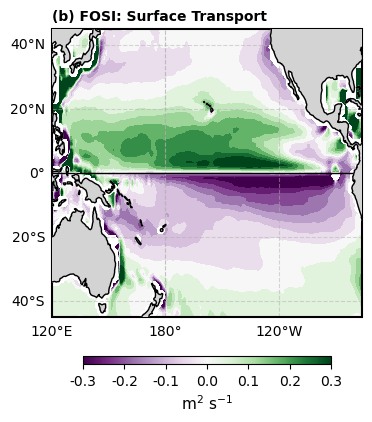

In [33]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-0.3, vmax=0.3, levels=14, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-0.3, 0.3))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label(r'm$^2$ s$^{-1}$', fontsize=11)
# tick_values = [-0.5, -0.25, 0., 0.25, 0.5]
tick_values = [-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
# tick_values = [-0.1, -0.05, 0, 0.05, 0.1]
# tick_values = [-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15] #[-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(b) FOSI: Surface Transport', fontsize=10, fontweight='bold', zorder=12, loc='left')

plt.show()

In [35]:
diff_1deg_wzeros = regrid_SMYLE(lens_ds.mean(dim='ensemble'))
# # diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.mean(dim='ensemble'))

diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

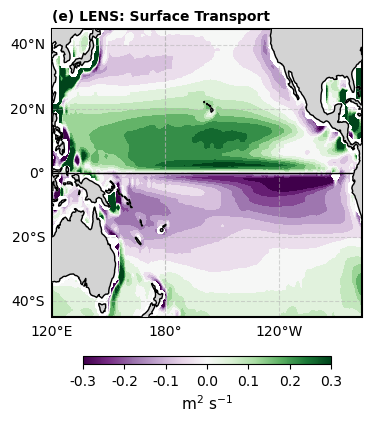

In [36]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-0.3, vmax=0.3, levels=14, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-0.3, 0.3))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label(r'm$^2$ s$^{-1}$', fontsize=11)
# tick_values = [-0.5, -0.25, 0., 0.25, 0.5]
tick_values = [-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
# tick_values = [-0.1, -0.05, 0, 0.05, 0.1]
# tick_values = [-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15] #[-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(e) LENS: Surface Transport', fontsize=10, fontweight='bold', zorder=12, loc='left')

plt.show()

In [37]:
diff_1deg_wzeros = regrid_SMYLE(lens_ds.std(dim='ensemble'))
# # diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.mean(dim='ensemble'))

diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

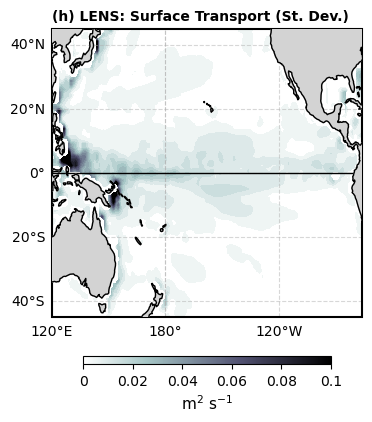

In [46]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='bone_r', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=0, vmax=0.1, levels=21, alpha=1)

#### COLORBAR
# density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-0.3, 0.3))
density_sm = plt.cm.ScalarMappable(cmap='bone_r', norm=plt.Normalize(0, 0.1))

density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label(r'm$^2$ s$^{-1}$', fontsize=11)
# tick_values = [-0.05, -0.025, 0., 0.025, 0.05]
tick_values = [0, 0.02, 0.04, 0.06, 0.08, 0.10]
# tick_values = [-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
# tick_values = [-0.1, -0.05, 0, 0.05, 0.1]
# tick_values = [-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15] #[-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(h) LENS: Surface Transport (St. Dev.)', fontsize=10, fontweight='bold', zorder=12, loc='left')

plt.show()

In [47]:
file_paths = [f'/glade/derecho/scratch/cassiacai/total_subduction_rate_{i}.nc' for i in ensemble_members]
ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)
ds.coords['ensemble'] = range(10)
total_subduction = ds['__xarray_dataarray_variable__'].compute()

/glade/derecho/scratch/cassiacai/tmp/ipykernel_66010/1194049705.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)


In [96]:
lens_subduction_mean = total_subduction.isel(time=slice(0, 240)).mean(dim=('time')).mean(dim='ensemble')

In [78]:
lens_subduction_std = total_subduction.isel(time=slice(0, 240)).mean(dim=('time')).std(dim='ensemble')


In [54]:
fosi_t_subduction_r = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_total_subduction_rate.nc').__xarray_dataarray_variable__

In [55]:
fosi_subduction_mean = fosi_t_subduction_r.isel(time=slice(0, 240)).mean(dim='time')

In [92]:
diff_1deg_wzeros = regrid_SMYLE(lens_subduction_std)
# # diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.mean(dim='ensemble'))

diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

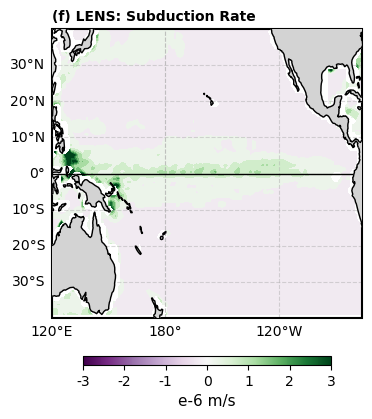

In [94]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-3e-6, vmax=3e-6, levels=14, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-3, 3))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('e-6 m/s', fontsize=11)
# tick_values = [-0.5, -0.25, 0., 0.25, 0.5]
tick_values = [-3, -2, -1, 0, 1, 2, 3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(f) LENS: Subduction Rate', fontsize=10, fontweight='bold', zorder=12, loc='left')
plt.ylim(-40, 40)
plt.show()

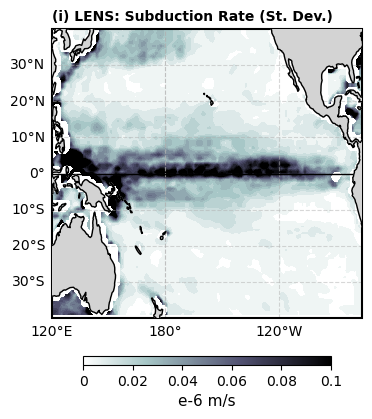

In [95]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='bone_r', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=0, vmax=1e-6, levels=21, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='bone_r', norm=plt.Normalize(0, 0.1))

density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('e-6 m/s', fontsize=11)
tick_values = [0, 0.02, 0.04, 0.06, 0.08, 0.10]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(i) LENS: Subduction Rate (St. Dev.)', fontsize=10, fontweight='bold', zorder=12, loc='left')
plt.ylim(-40, 40)
plt.show()

In [90]:
diff_1deg_wzeros = regrid_SMYLE(fosi_subduction_mean)
# # diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.mean(dim='ensemble'))

diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

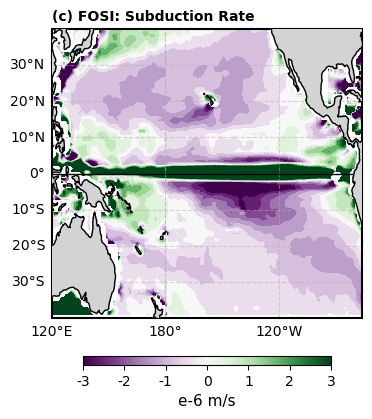

In [91]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-3e-6, vmax=3e-6, levels=14, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-3, 3))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('e-6 m/s', fontsize=11)
# tick_values = [-0.5, -0.25, 0., 0.25, 0.5]
tick_values = [-3, -2, -1, 0, 1, 2, 3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(c) FOSI: Subduction Rate', fontsize=10, fontweight='bold', zorder=12, loc='left')
plt.ylim(-40, 40)
plt.show()